# The paper's figures, drawn from their data

Each figure the paper draws with matplotlib has a directory `figures/<fig>/` holding `figdata/` (the arrays the figure shows) and `draw.py` (reads `figdata/`, draws, saves). A cell below draws one figure into `figures/out/<fig>/` (gitignored) and shows every file it writes: PDF pages rasterised by PyMuPDF at 110 dpi, PNGs scaled to the same 110 dpi from the resolution they store (the two MD snapshots of Fig. 5 store none and are shown 420 px wide).

**Builds.** Text placement depends on the freetype that matplotlib was built with, so each figure is drawn under the build its pixels were measured with: matplotlib 3.10.8 with freetype 2.14.1 (the conda-forge build that `env/environment.yml` installs into the aipf environment, `figures/common/BUILD.txt`) for all figures but the Supplementary coarsening rows, which were drawn with the pip wheel of matplotlib 3.10.8 (freetype 2.6.1, named by `BUILD` in their `draw.py`). Every figure is therefore drawn in a process of its own by `figures/common/render.py`, the same runner `tests/test_figures.py` uses, with the pip wheel first on that process's `PYTHONPATH` when the figure asks for it. The kernel itself never draws.

**The pip wheel.** It lives outside the environment, under the data farm (`<data>/tools/matplotlib-3.10.8-wheel`, `data/` by default), and is installed with the command below. It needs the network, and its sha256 pins the CPython 3.12 wheel for x86-64 Linux, so pip refuses it on another interpreter or platform.

```
python figures/common/wheel.py
```

The coarsening cell stops with that command when the wheel is missing.

**Figure 5** is assembled by `latexmk` from its panels when the site declares it (`AIPF_LATEXMK`, or `latexmk` under `[site]` in `aipf.toml`). Without it the cell draws and shows the panels only and says that the assembled figure was skipped.

**Painted boxes.** The 3-D boxes of Extended Data Fig. 1 and Supplementary Fig. S1 ship pre-rendered in their `figdata/` (RGBA PNG layers at 600 dpi, the resolution of the PNGs they appear in), and `draw.py` composites them under box edges and labels that matplotlib still draws, so every figure draws in seconds. Set `AIPF_FIGURES_RENDER_3D=1` (or `true`, `yes`; exported before starting Jupyter, or `%env AIPF_FIGURES_RENDER_3D=1` before running the cells) to paint the boxes from the fields again, about 6 minutes for each of the two figures, which rewrites those layers before compositing them.

Run with *Kernel → Restart & Run All*. The whole notebook takes about a minute.

In [1]:
import json, os, re, shutil, subprocess, sys, time
import importlib.util
from io import BytesIO
from pathlib import Path

from IPython.display import Image, display

REPO = next(p for p in (Path.cwd(), *Path.cwd().parents)
            if (p / "figures" / "common" / "render.py").is_file())
FIGURES = REPO / "figures"
COMMON = FIGURES / "common"
OUT = FIGURES / "out"
SHOW_DPI = 110


def _load(path, name):
    spec = importlib.util.spec_from_file_location(name, path)
    mod = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(mod)
    return mod


wheel = _load(COMMON / "wheel.py", "figures_common_wheel")   # the pip build of matplotlib
box3d = _load(COMMON / "box3d.py", "figures_common_box3d")   # paint_requested, as draw.py reads it


def build_of(fig):
    """The matplotlib build a figure is drawn with: BUILD in its draw.py, else common/BUILD.txt."""
    src = (FIGURES / fig / "draw.py").read_text()
    for line in src.splitlines():
        if line.startswith("BUILD = "):
            return line.split("=", 1)[1].strip().strip("\"'")
    return (COMMON / "BUILD.txt").read_text().strip()


def parse_build(text):
    """("3.10.8", "2.6.1") from "matplotlib 3.10.8, freetype 2.6.1"."""
    m = re.fullmatch(r"matplotlib\s+(\S+),\s*freetype\s+(\S+)", text.strip())
    if not m:
        raise ValueError(f"not a build line: {text!r}")
    return m.groups()


def child_env(fig, build):
    """The drawing process's environment: the pip wheel first on PYTHONPATH for a figure
    drawn with it, and never otherwise (as in tests/test_figures.py)."""
    target = wheel.wheel_dir()
    env = dict(os.environ, MPLBACKEND="Agg")
    path = [p for p in env.get("PYTHONPATH", "").split(os.pathsep)
            if p and Path(p).resolve() != target.resolve()]
    if parse_build(build) == parse_build(wheel.BUILD):
        if not wheel.present(target):
            raise RuntimeError(f"{fig} is drawn with {build}, the pip wheel of matplotlib, which "
                               f"is not installed. Install it with: python figures/common/wheel.py")
        path.insert(0, str(target))
    env["PYTHONPATH"] = os.pathsep.join(path)
    return env


def boxes_mode(fig):
    """How a figure with painted 3-D boxes drew them, read from the environment the drawing
    process inherits ("" for a figure without them)."""
    if "box3d.paint_requested" not in (FIGURES / fig / "draw.py").read_text():
        return ""
    paint = box3d.paint_requested(os.environ)
    return (", 3-D boxes painted from the fields and their layers rewritten" if paint
            else ", 3-D boxes from the stored layers")


def draw(fig):
    """Draw figures/<fig> from its figdata into figures/out/<fig>/, in a process of its own
    under the figure's build; return the files it wrote."""
    out = OUT / fig
    shutil.rmtree(out, ignore_errors=True)
    out.mkdir(parents=True)
    build = build_of(fig)
    t0 = time.time()
    run = subprocess.run([sys.executable, str(COMMON / "render.py"), str(FIGURES / fig / "draw.py"),
                          str(out), build], env=child_env(fig, build), capture_output=True, text=True)
    if run.returncode != 0:
        raise RuntimeError(f"{fig}: drawing failed (exit {run.returncode})\n{run.stderr[-3000:]}")
    files = [Path(p) for p in json.loads(run.stdout.strip().splitlines()[-1])["files"]]
    print(f"{fig}: {len(files)} file(s) in {time.time() - t0:.0f} s, {build}{boxes_mode(fig)}")
    return files


def _png(im):
    buf = BytesIO()
    im.save(buf, "PNG", optimize=True)
    return Image(buf.getvalue(), format="png")


def show(files):
    """Every page of every file: PDFs rasterised at 110 dpi, PNGs on white, scaled to 110 dpi
    from their stored resolution, or 420 px wide when they store none."""
    import fitz
    from PIL import Image as PImage
    for f in files:
        f = Path(f)
        print(f.relative_to(REPO))
        if f.suffix == ".pdf":
            for page in fitz.open(f):
                display(Image(page.get_pixmap(dpi=SHOW_DPI).tobytes("png"), format="png"))
        else:
            im = PImage.open(f)
            dpi = (im.info.get("dpi") or (None,))[0]
            width = round(im.width * SHOW_DPI / dpi) if dpi else min(im.width, 420)
            im = im.convert("RGBA")
            bg = PImage.new("RGBA", im.size, "white")
            bg.alpha_composite(im)
            im = bg.convert("RGB").resize((width, round(im.height * width / im.width)),
                                          PImage.LANCZOS)
            display(_png(im))

print("pip wheel of matplotlib:", "installed" if wheel.present()
      else "not installed (python figures/common/wheel.py installs it)")

pip wheel of matplotlib: installed


## Main text

Fig. 1 (`figures/reference/fig1_updated.pdf`, TikZ) and Fig. 2 (`figures/reference/framework.pdf`, Figma) are schematics with no data behind them. `figures/reference/` holds them as published, and no cell draws them.

fig3_lj: 2 file(s) in 2 s, matplotlib 3.10.8, freetype 2.14.1
figures/out/fig3_lj/fig3a_pd_baselines_1col.pdf


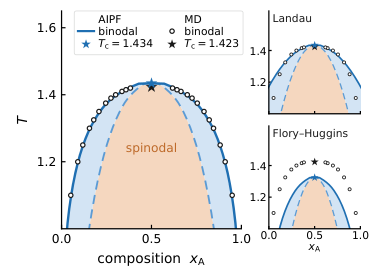

figures/out/fig3_lj/fig3_growth_baselines_1col.pdf


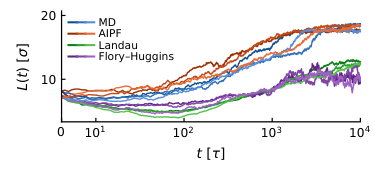

In [2]:
# Fig. 3: binary Lennard-Jones phase diagram (a) and domain growth at T = 1.20 (b)
show(draw("fig3_lj"))

fig4_feb: 1 file(s) in 1 s, matplotlib 3.10.8, freetype 2.14.1
figures/out/fig4_feb/feb_composite.pdf


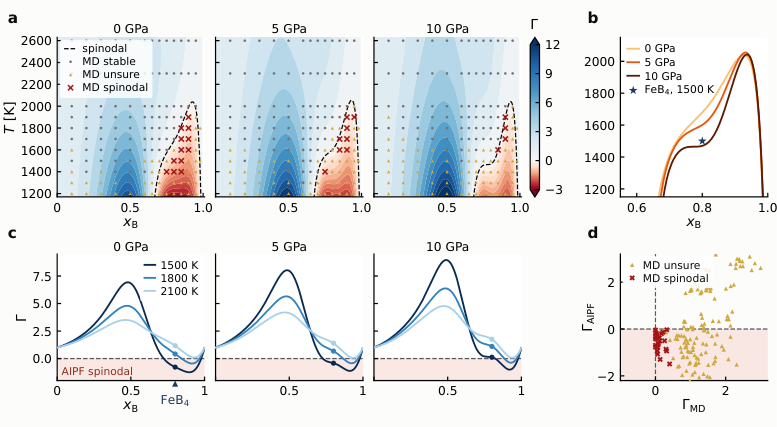

In [3]:
# Fig. 4: iron-boron thermodynamic factor maps, spinodals, isotherms and the MD parity
show(draw("fig4_feb"))

fig5_hhe: 9 file(s) in 13 s, matplotlib 3.10.8, freetype 2.14.1
figures/out/fig5_hhe/hhe_main_b.png


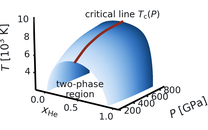

figures/out/fig5_hhe/hhe_main_c.pdf


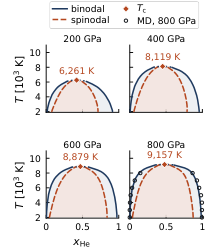

figures/out/fig5_hhe/hhe_main_a.pdf


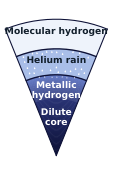

figures/out/fig5_hhe/hhe_main_lit.pdf


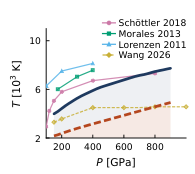

figures/out/fig5_hhe/hhe_main_d.pdf


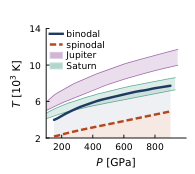

figures/out/fig5_hhe/md_snapshot_T05000_slab.png


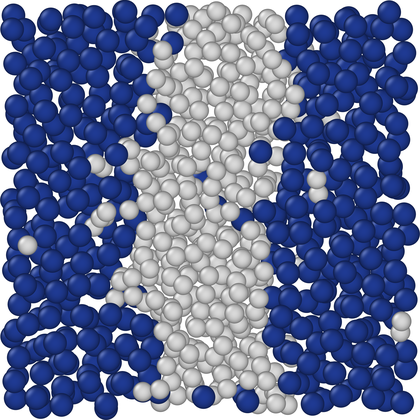

figures/out/fig5_hhe/md_snapshot_T10000_slab.png


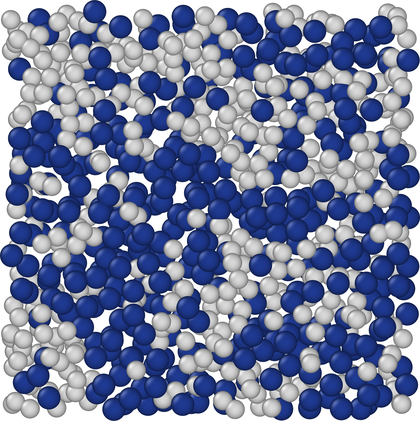

figures/out/fig5_hhe/hhe_main_fg.pdf


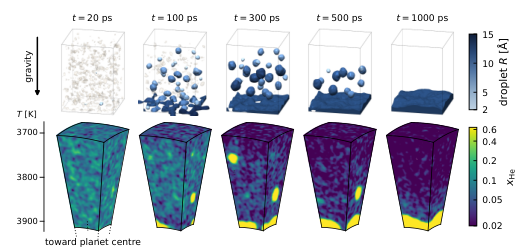

figures/out/fig5_hhe/fig_hhe_main.pdf


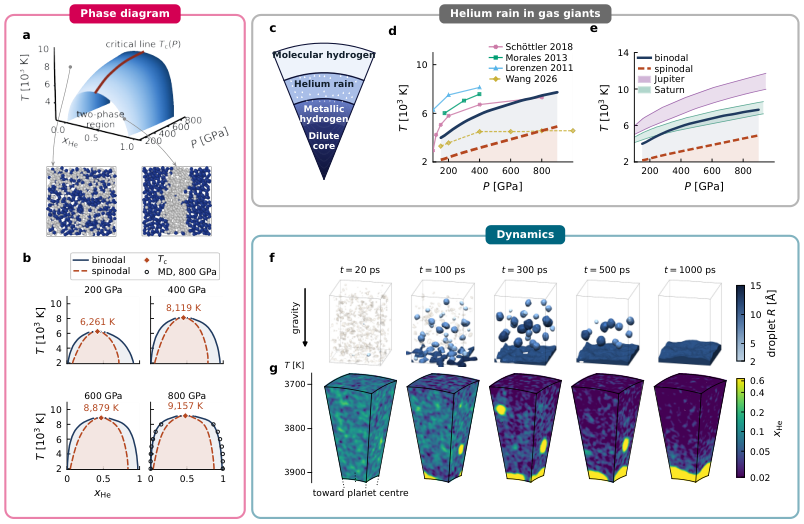

In [4]:
# Fig. 5: hydrogen-helium phase diagram and helium rain; the panels, then the assembled figure
files = draw("fig5_hhe")
if not any(f.name == "fig_hhe_main.pdf" for f in files):
    print("fig_hhe_main.pdf: skipped, latexmk is not declared (AIPF_LATEXMK, or latexmk under [site] in aipf.toml)")
show(files)

## Extended Data

ed1_lj_vext: 2 file(s) in 7 s, matplotlib 3.10.8, freetype 2.14.1, 3-D boxes from the stored layers
figures/out/ed1_lj_vext/ed_lj_vext_hexagonal.png


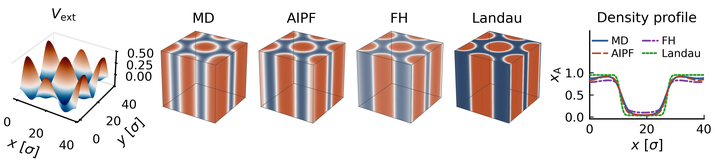

figures/out/ed1_lj_vext/ed_lj_vext_checkerboard.png


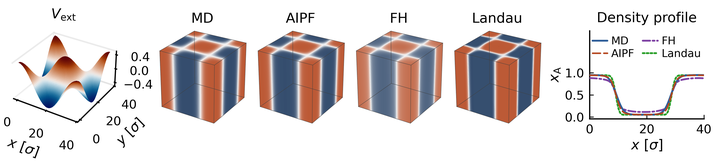

In [5]:
# Extended Data Fig. 1: equilibria under an external potential, MD against AIPF, Flory-Huggins and Landau
show(draw("ed1_lj_vext"))

ed2_lj_slab: 5 file(s) in 2 s, matplotlib 3.10.8, freetype 2.14.1
figures/out/ed2_lj_slab/ed_lj_slab_b.pdf


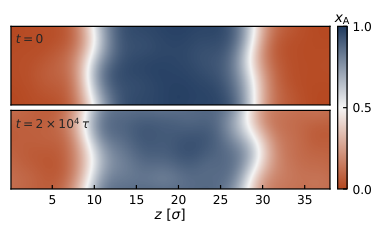

figures/out/ed2_lj_slab/ed_lj_slab_c.pdf


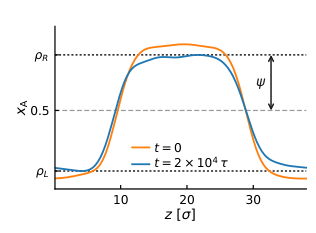

figures/out/ed2_lj_slab/ed_lj_slab_landau.pdf


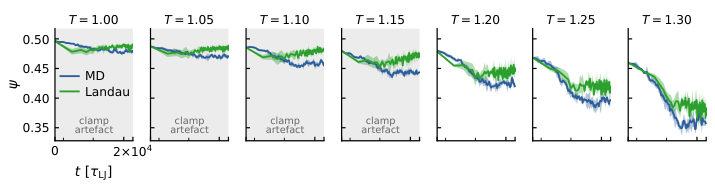

figures/out/ed2_lj_slab/ed_lj_slab_fh.pdf


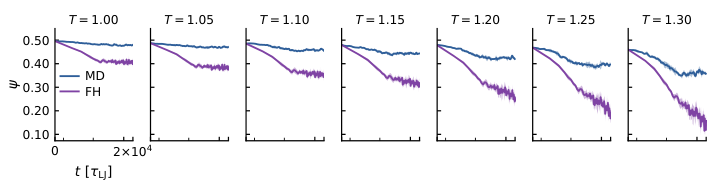

figures/out/ed2_lj_slab/ed_lj_slab_aipf.pdf


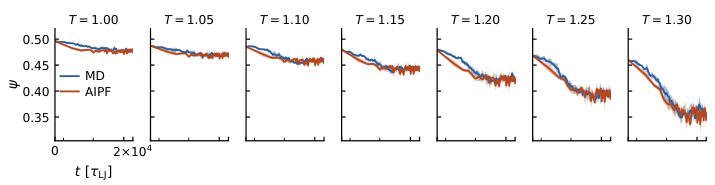

In [6]:
# Extended Data Fig. 2: relaxation of an MD slab interface, MD against AIPF, Flory-Huggins and Landau
show(draw("ed2_lj_slab"))

ed3_feb_dgmix: 1 file(s) in 1 s, matplotlib 3.10.8, freetype 2.14.1
figures/out/ed3_feb_dgmix/ed_feb_dgmix.pdf


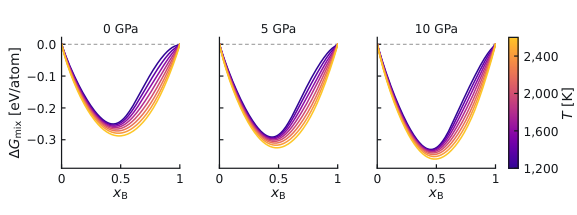

In [7]:
# Extended Data Fig. 3: iron-boron free energy of mixing at 0, 5 and 10 GPa
show(draw("ed3_feb_dgmix"))

ed4_hhe_scaling: 1 file(s) in 1 s, matplotlib 3.10.8, freetype 2.14.1
figures/out/ed4_hhe_scaling/ed_hhe_scaling.pdf


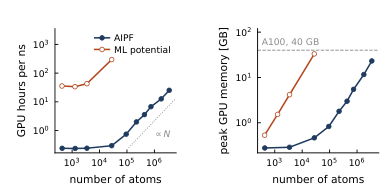

In [8]:
# Extended Data Fig. 4: cost of AIPF against MD with the ML potential
show(draw("ed4_hhe_scaling"))

ed5_hhe_dgmix_gamma: 2 file(s) in 1 s, matplotlib 3.10.8, freetype 2.14.1
figures/out/ed5_hhe_dgmix_gamma/ed_hhe_dgmix.pdf


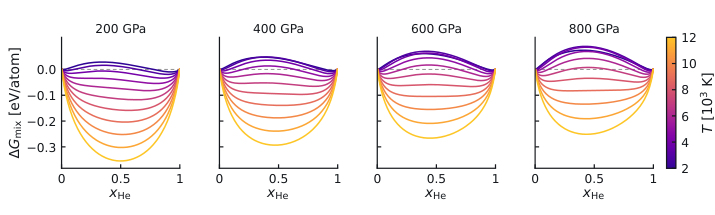

figures/out/ed5_hhe_dgmix_gamma/ed_hhe_gamma.pdf


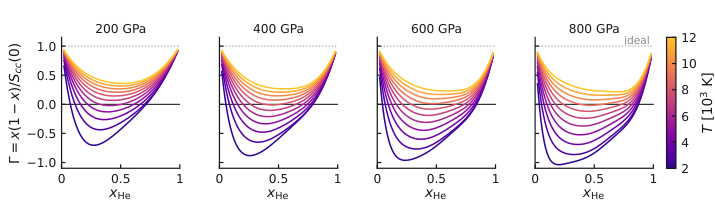

In [9]:
# Extended Data Fig. 5: hydrogen-helium free energy of mixing (a) and thermodynamic factor (b)
show(draw("ed5_hhe_dgmix_gamma"))

ed6_lj_free_energy: 2 file(s) in 1 s, matplotlib 3.10.8, freetype 2.14.1
figures/out/ed6_lj_free_energy/fig2a_free_energy.pdf


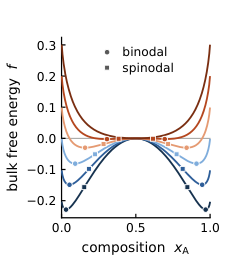

figures/out/ed6_lj_free_energy/fig2b_curvature.pdf


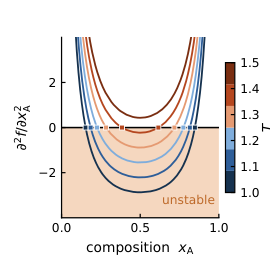

In [10]:
# Extended Data Fig. 6: AIPF bulk free energy (a) and its curvature (b), binary Lennard-Jones
show(draw("ed6_lj_free_energy"))

ed7_hhe_nx: 1 file(s) in 1 s, matplotlib 3.10.8, freetype 2.14.1
figures/out/ed7_hhe_nx/ed_hhe_nx.pdf


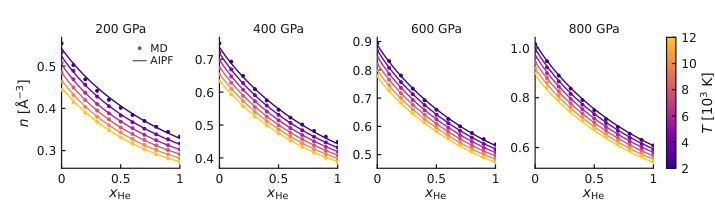

In [11]:
# Extended Data Fig. 7: hydrogen-helium number density along isobars, MD against AIPF
show(draw("ed7_hhe_nx"))

ed8_hhe_anchors: 1 file(s) in 1 s, matplotlib 3.10.8, freetype 2.14.1
figures/out/ed8_hhe_anchors/fig_anchor_parity.png


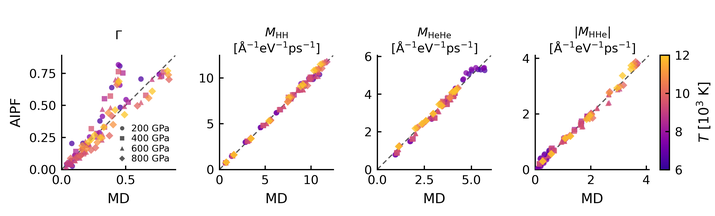

In [12]:
# Extended Data Fig. 8: AIPF against MD at the training anchors, thermodynamic factor and mobility
show(draw("ed8_hhe_anchors"))

## Supplementary information

sm_lj_coarsening: 8 file(s) in 4 s, matplotlib 3.10.8, freetype 2.6.1, 3-D boxes from the stored layers
figures/out/sm_lj_coarsening/supp_fig2e_coarsening_T1.10.png


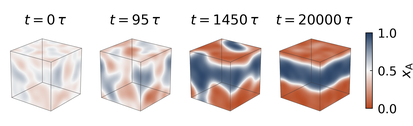

figures/out/sm_lj_coarsening/supp_fig2f_growth_T1.10.pdf


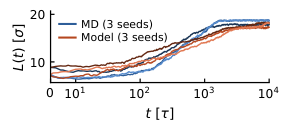

figures/out/sm_lj_coarsening/supp_fig2e_coarsening_T1.15.png


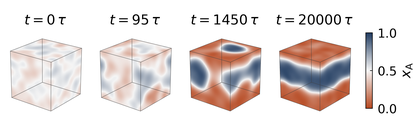

figures/out/sm_lj_coarsening/supp_fig2f_growth_T1.15.pdf


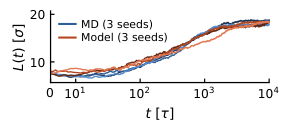

figures/out/sm_lj_coarsening/supp_fig2e_coarsening_T1.25.png


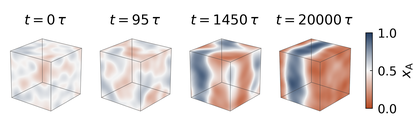

figures/out/sm_lj_coarsening/supp_fig2f_growth_T1.25.pdf


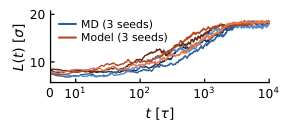

figures/out/sm_lj_coarsening/supp_fig2e_coarsening_T1.30.png


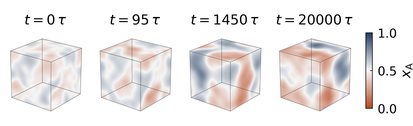

figures/out/sm_lj_coarsening/supp_fig2f_growth_T1.30.pdf


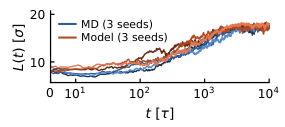

In [13]:
# Supplementary Fig. S1: spinodal coarsening of binary Lennard-Jones at T = 1.10, 1.15, 1.25, 1.30 (pip wheel of matplotlib)
show(draw("sm_lj_coarsening"))

sm_feb_nx: 1 file(s) in 1 s, matplotlib 3.10.8, freetype 2.14.1
figures/out/sm_feb_nx/ed_feb_nx.pdf


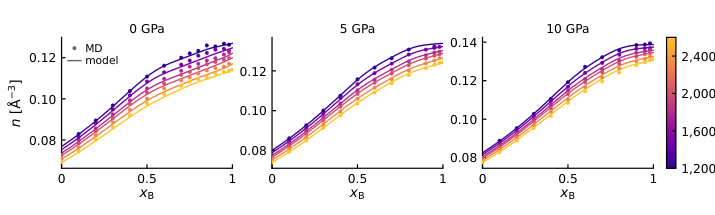

In [14]:
# Supplementary Fig. S2: iron-boron number density along the 0, 5 and 10 GPa isobars, MD against AIPF
show(draw("sm_feb_nx"))

sm_hhe_coverage: 1 file(s) in 1 s, matplotlib 3.10.8, freetype 2.14.1
figures/out/sm_hhe_coverage/ed_hhe_coverage.pdf


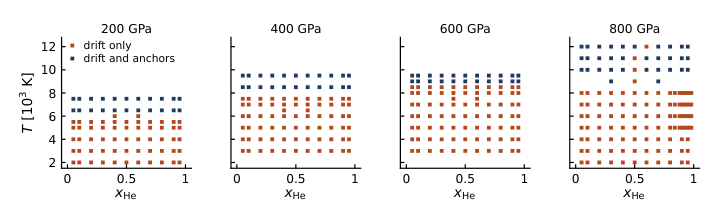

In [15]:
# Supplementary Fig. S3: hydrogen-helium training states at 200 to 800 GPa
show(draw("sm_hhe_coverage"))